In [1]:
import os, io, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from datetime import datetime
warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, pipeline as hf_pipeline,
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, accuracy_score,
)
from sklearn.utils.class_weight import compute_class_weight
from sentence_transformers import SentenceTransformer
import faiss
from reportlab.lib.pagesizes import A4
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer,
    Table, TableStyle, Image as RLImage, HRFlowable,
)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.units import inch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

CFG = {
    'img_size': 224,
    'batch_size': 128,
    'num_epochs': 10,
    'lr': 1e-4,
    'weight_decay': 1e-4,
#num_workers is 2 for colab and windows AI machine 0
#    'num_workers': 2,
    'num_workers': 2,
    'seed': 42,
    'confidence_threshold': 0.70,
    'model_save_path': '/content/skin_model_ep40.pth',
    'report_dir': '/content/reports/',
}
os.makedirs(CFG['report_dir'], exist_ok=True)
torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
print('Config ready')

Device: cuda
Config ready


In [2]:
from pathlib import Path
from datasets import load_dataset, DatasetDict

data_dir = Path(r"final_balanced_8class_images\final_balanced_8class_images")
raw = DatasetDict({
    "train": load_dataset("imagefolder", data_dir=str(data_dir), split="train")
})
# print( raw)
if "validation" not in raw and "test" not in raw:
    split = raw["train"].train_test_split(
        test_size=0.2,
        stratify_by_column="label",
        seed=CFG["seed"],
    )
    raw = DatasetDict({
        "train": split["train"],
        "validation": split["test"],
    })
# print( raw)

sample = raw["train"][0]
label_col = "label" if "label" in sample else "labels"
img_col = "image" if "image" in sample else "img"

if hasattr(raw["train"].features[label_col], "names"):
    CLASS_NAMES = list(raw["train"].features[label_col].names)
else:
    CLASS_NAMES = sorted({str(x) for x in raw["train"][label_col]})
# print( CLASS_NAMES )
NUM_CLASSES = len(CLASS_NAMES)
MAL_KW = ['cancer','melanoma','carcinoma','malignant','akiec','bcc','scc','mel']
MALIGNANT = [any(k in c.lower() for k in MAL_KW) for c in CLASS_NAMES]
# print(MALIGNANT)


print(f"Loaded dataset from: {data_dir}")
print(f"Splits: {list(raw.keys())}")
print(f"Train size: {len(raw['train'])}")
if "validation" in raw:
    print(f"Validation size: {len(raw['validation'])}")
if "test" in raw:
    print(f"Test size: {len(raw['test'])}")
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Resolving data files:   0%|          | 0/17361 [00:00<?, ?it/s]

Loaded dataset from: final_balanced_8class_images\final_balanced_8class_images
Splits: ['train', 'validation']
Train size: 13888
Validation size: 3472
Classes (8): ['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']


In [3]:
# ======= DATA LOADER DEFINITION (IN-RAM CACHING) ============
import torch.multiprocessing as mp
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import os
from tqdm import tqdm  # Helpful to see the loading progress bar

# Set multiprocessing for Windows
try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class SkinDS(Dataset):
    def __init__(self, split, tf, split_name="Dataset"):
        self.tf = tf
        self.cached_images = []
        self.labels = []
        
        print(f"Pre-loading {split_name} into system RAM...")
        # Loop through the split once and cache everything
        for i in tqdm(range(len(split))):
            item = split[i]
            img = item[img_col]
            
            # Convert raw format to standard RGB PIL Image
            if not isinstance(img, Image.Image):
                img = Image.fromarray(np.array(img))
            img = img.convert('RGB')
            
            # Cache the clean base image and its label in memory
            self.cached_images.append(img)
            self.labels.append(torch.tensor(item[label_col], dtype=torch.long))
            
        print(f"Finished caching {len(self.cached_images)} images in RAM.\n")

    def __len__(self): 
        return len(self.cached_images)
        
    def __getitem__(self, i):
        # Read directly from RAM array instead of disk/dataframe
        img = self.cached_images[i]
        label = self.labels[i]
        
        # Apply random augmentations dynamically per epoch
        if self.tf: 
            img = self.tf(img)
            
        return img, label

# Instantiate the Datasets (This will trigger the initial RAM cache loop)
val_split = raw.get('validation', raw.get('test', raw['train']))

train_ds = SkinDS(raw['train'], train_tf, split_name="Train Set")
val_ds = SkinDS(val_split, val_tf, split_name="Validation Set")

print(f'Train {len(train_ds)} | Val {len(val_ds)}')
print(CFG)

Pre-loading Train Set into system RAM...


100%|██████████| 13888/13888 [14:44<00:00, 15.70it/s]


Finished caching 13888 images in RAM.

Pre-loading Validation Set into system RAM...


100%|██████████| 3472/3472 [03:42<00:00, 15.60it/s]

Finished caching 3472 images in RAM.

Train 13888 | Val 3472
{'img_size': 224, 'batch_size': 128, 'num_epochs': 10, 'lr': 0.0001, 'weight_decay': 0.0001, 'num_workers': 2, 'seed': 42, 'confidence_threshold': 0.7, 'model_save_path': '/content/skin_model_ep40.pth', 'report_dir': '/content/reports/'}


In [4]:
# ============ Windows-Safe DataLoader Function ============
def create_dataloader_win(dataset, batch_size, shuffle=True, num_workers=0): # Set default to 0
    """
    Creates a DataLoader that reliably works on Windows with CUDA
    """
    # Force 0 workers on Windows when caching in RAM to avoid pickling deadlocks
    if os.name == 'nt':
        num_workers = 0  
    
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=True,  # Keeps data transfers to your 4 GPUs fast
        persistent_workers=False,  
        prefetch_factor=None, # Must be None if num_workers == 0
        drop_last=False
    )

# Create your DataLoaders with 0 workers
train_loader = create_dataloader_win(train_ds, CFG['batch_size'], shuffle=True, num_workers=0)
val_loader = create_dataloader_win(val_ds, CFG['batch_size'], shuffle=False, num_workers=0)

print(f"Train loader workers: {train_loader.num_workers}")
print(f"Val loader workers: {val_loader.num_workers}")

# ============ Test DataLoader ============
print("\nTesting DataLoader...")
try:
    for i, (x, y) in enumerate(train_loader):
        print(f"   Batch {i}: x={x.shape}, y={y.shape}")
        if i >= 1:
            break
    print("DataLoader test successful!")
except Exception as e:
    print(f"DataLoader test failed: {e}")

Train loader workers: 0
Val loader workers: 0

Testing DataLoader...
   Batch 0: x=torch.Size([128, 3, 224, 224]), y=torch.Size([128])
   Batch 1: x=torch.Size([128, 3, 224, 224]), y=torch.Size([128])
DataLoader test successful!


In [5]:
import torch.nn as nn
from torchvision import models

NUM_CLASSES = 8  # keep same as your dataset

def get_mobilenet_model(num_classes):
    model = models.mobilenet_v3_large(weights="IMAGENET1K_V1")
    
    # Replace classifier head
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    
    return model

In [6]:
# ========= MAMBA model definition & Multi-GPU Configuration =========
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from dotenv import load_dotenv
load_dotenv()

class MambaBlock(nn.Module):
    def __init__(self, d, d_state=16, d_conv=4, expand=2):
        super().__init__()
        di = int(expand * d)
        self.di      = di
        self.in_p    = nn.Linear(d, di * 2, bias=False)
        self.conv    = nn.Conv1d(di, di, d_conv, padding=d_conv-1, groups=di)
        self.x_p     = nn.Linear(di, d_state*2+di, bias=False)
        self.dt_p    = nn.Linear(d_state, di, bias=True)
        self.A_log   = nn.Parameter(
            torch.log(torch.arange(1, d_state+1, dtype=torch.float32)
                      .unsqueeze(0).expand(di, -1)))
        self.D       = nn.Parameter(torch.ones(di))
        self.out_p   = nn.Linear(di, d, bias=False)
        self.norm    = nn.LayerNorm(d)

    def forward(self, x):
        B, L, D = x.shape; r = x
        x  = self.norm(x)
        xz = self.in_p(x)
        x_, z = xz.chunk(2, dim=-1)
        x_ = self.conv(x_.transpose(1, 2))[:, :, :L].transpose(1, 2)
        x_ = F.silu(x_)
        proj = self.x_p(x_)
        ds = self.A_log.shape[-1]
        dt, _, _ = proj.split([ds, ds, self.di], dim=-1)
        dt = F.softplus(self.dt_p(dt))
        y  = x_ * dt.sigmoid() + x_ * self.D[None, None, :]
        y  = y * F.silu(z)
        return self.out_p(y) + r

class MambaEnc(nn.Module):
    def __init__(self, img=224, patch=16, d=256, n=4):
        super().__init__()
        np_ = (img // patch) ** 2
        pd  = 3 * patch * patch
        self.uf  = nn.Unfold(patch, stride=patch)
        self.pr  = nn.Linear(pd, d)
        self.pe  = nn.Parameter(torch.randn(1, np_, d) * 0.02)
        self.blk = nn.ModuleList([MambaBlock(d) for _ in range(n)])
        self.ln  = nn.LayerNorm(d)
    def forward(self, x):
        t = self.pr(self.uf(x).transpose(1, 2)) + self.pe
        for b in self.blk: t = b(t)
        return self.ln(t).mean(1)

class FusionModel(nn.Module):
    def __init__(self, nc, img=224, drop=0.3):
        super().__init__()
        self.cn  = timm.create_model('convnextv2_base', pretrained=True, num_classes=0)
        self.vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        self.mb  = MambaEnc(img=img)
        P = 512
        self.pc  = nn.Sequential(nn.Linear(self.cn.num_features, P), nn.GELU())
        self.pv  = nn.Sequential(nn.Linear(self.vit.num_features, P), nn.GELU())
        self.pm  = nn.Sequential(nn.Linear(256, P), nn.GELU())
        self.w   = nn.Parameter(torch.ones(3))
        self.head= nn.Sequential(
            nn.LayerNorm(P), nn.Dropout(drop),
            nn.Linear(P, 256), nn.GELU(),
            nn.Dropout(drop / 2), nn.Linear(256, nc),
        )
    def forward(self, x):
        w = F.softmax(self.w, dim=0)
        f = w[0]*self.pc(self.cn(x)) + w[1]*self.pv(self.vit(x)) + w[2]*self.pm(self.mb(x))
        return self.head(f)

# 2. Set device targeting generic 'cuda' context
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Instantiate the base model architecture
# model = FusionModel(NUM_CLASSES)
model = get_mobilenet_model(NUM_CLASSES).to(DEVICE)

# 4. Wrap and optimize across multi-GPU environments
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs for parallel execution!")
    model = nn.DataParallel(model)
    model = model.to(DEVICE)
    
    # Compile the DataParallel wrapper to fuse CUDA kernels across devices
    model = torch.compile(model)
else:
    print("Using 1 GPU configuration.")
    model = model.to(DEVICE)

# 5. Extract uncompiled/unwrapped module cleanly to get parameters
base_model = model.module if isinstance(model, nn.DataParallel) else model
# Unpack if compiled
if hasattr(base_model, '_orig_mod'):
    base_model = base_model._orig_mod

print(f'Model: {sum(p.numel() for p in base_model.parameters())/1e6:.1f}M params')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to C:\Users\1543076/.cache\torch\hub\checkpoints\mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:07<00:00, 3.13MB/s]


Using 4 GPUs for parallel execution!
Model: 4.2M params


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, 
    f1_score, 
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    auc
)

def generate_evaluation_suite(y_true, y_pred, y_prob, class_names):
    """
    Generates a full evaluation matrix report and plots ROC Curves & Confusion Matrix.
    
    y_true: List or array of true labels (TA)
    y_pred: List or array of predicted classes (PA)
    y_prob: List or array of raw probabilities (PR)
    class_names: List of strings containing class names
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    num_classes = len(class_names)
    
    print("==================================================")
    # 1. Standard Classification Report (Precision, Recall, F1 per class)
    print("CLASSIFICATION REPORT:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # 2. Micro F1-Score
    micro_f1 = f1_score(y_true, y_pred, average='micro')
    print(f"F1 Micro Score: {micro_f1:.4f}")
    
    # 3. Multi-class AUC-ROC Score (One-vs-Rest strategy)
    auc_roc_ovr = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    print(f"Global AUC-ROC (Macro OVR): {auc_roc_ovr:.4f}")
    print("==================================================\n")
    
    # --- PLOTTING SECTION ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot A: Confusion Matrix Heatmap
    cm = confusion_matrix(y_true, y_pred)
    # Normalize by row (true labels)
    cm_ratio = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Combine raw counts and percentages for annotations
    labels = (np.array([f"{count}\n({ratio:.1%})" 
                        for count, ratio in zip(cm.flatten(), cm_ratio.flatten())])
              .reshape(num_classes, num_classes))
    
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", 
                xticklabels=class_names, yticklabels=class_names, ax=axes[0], cbar=False)
    axes[0].set_title("Confusion Matrix (Counts & Recall %)", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Predicted Label", fontsize=12)
    axes[0].set_ylabel("True Label", fontsize=12)
    
    # Plot B: One-vs-Rest ROC Curves
    for i in range(num_classes):
        # Create binary targets for the current class
        y_true_binary = (y_true == i).astype(int)
        fpr, tpr, _ = roc_curve(y_true_binary, y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
        
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_title("One-vs-Rest (OVR) ROC Curves", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("False Positive Rate", fontsize=12)
    axes[1].set_ylabel("True Positive Rate", fontsize=12)
    axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

W0703 00:53:25.266000 40116 site-packages\torch\_logging\_internal.py:1081] [0/0] Profiler function <class 'torch.autograd.profiler.record_function'> will be ignored


Ep 1 | trL=1.5086 trA=0.4988 | vlL=1.3442 vlA=0.5706 bal=0.5706 BEST
Ep 2 | trL=1.1954 trA=0.6544 | vlL=1.1490 vlA=0.6754 bal=0.6754 BEST
Ep 3 | trL=1.1047 trA=0.6974 | vlL=1.0734 vlA=0.7241 bal=0.7241 BEST
Ep 4 | trL=1.0509 trA=0.7292 | vlL=1.0449 vlA=0.7399 bal=0.7399 BEST
Ep 5 | trL=1.0271 trA=0.7433 | vlL=1.0373 vlA=0.7411 bal=0.7411 BEST
Ep 6 | trL=1.0212 trA=0.7458 | vlL=1.0126 vlA=0.7451 bal=0.7451 BEST
Ep 7 | trL=0.9794 trA=0.7617 | vlL=0.9900 vlA=0.7621 bal=0.7621 BEST
Ep 8 | trL=0.9347 trA=0.7903 | vlL=0.9632 vlA=0.7730 bal=0.7730 BEST
Ep 9 | trL=0.9026 trA=0.8026 | vlL=0.9518 vlA=0.7834 bal=0.7834 BEST
Ep10 | trL=0.8689 trA=0.8225 | vlL=0.9288 vlA=0.7895 bal=0.7895 BEST
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          AK       0.82      0.61      0.70       434
         BCC       0.67      0.84      0.75       434
         BKL       0.68      0.72      0.70       434
          DF       0.96      0.94      0.95       434
         MEL    

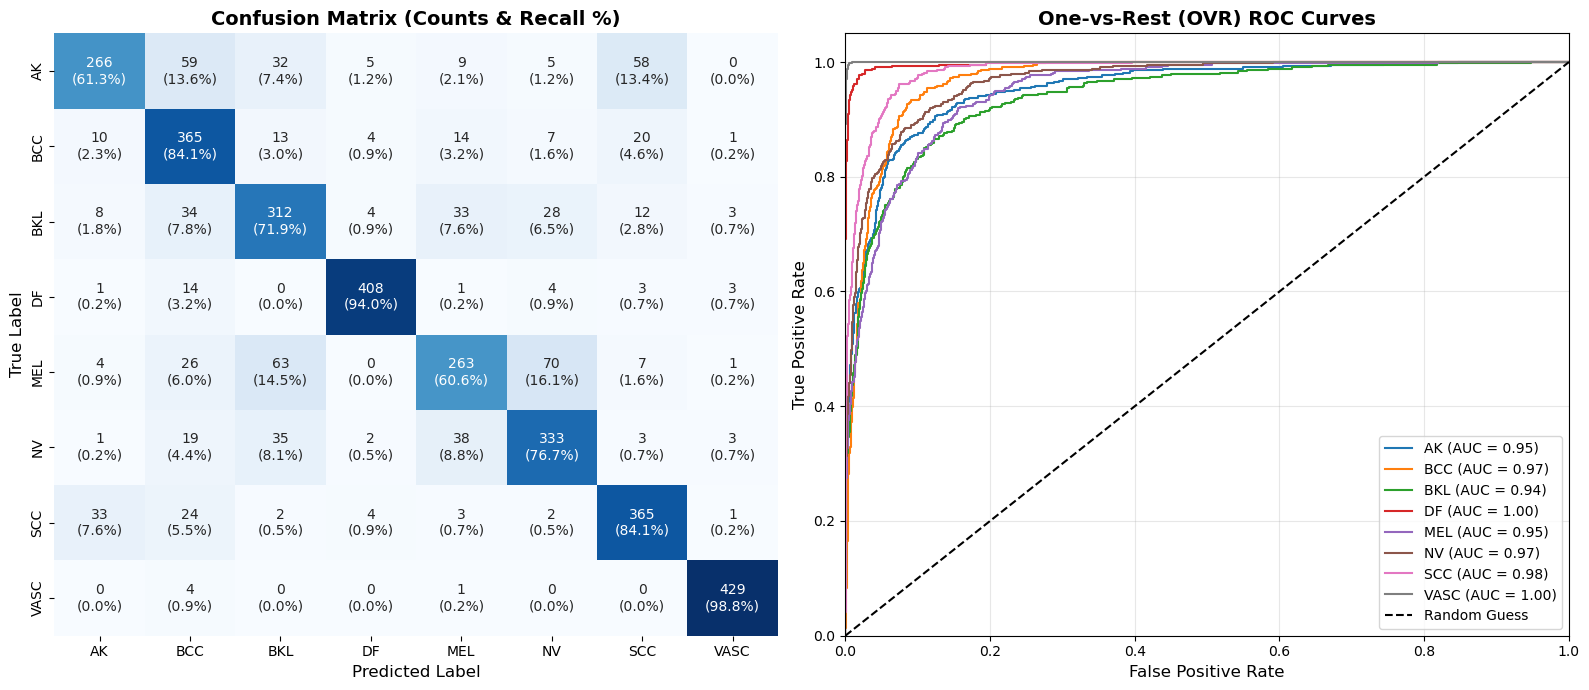

Best balanced accuracy: 0.7895


In [8]:
# ========= Loss, Optimizer, and Parallel Training Loops =========
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import balanced_accuracy_score

# 1. Compute class weights and setup loss on the global device
cw  = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=raw['train'][label_col])
crt = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32).to(DEVICE), label_smoothing=0.1)

# 2. Setup Optimizer connecting to the wrapped model parameters
opt = torch.optim.AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
sch = CosineAnnealingWarmRestarts(opt, T_0=5, T_mult=2, eta_min=1e-6)

# 3. Initialize Gradient Scaler for Automated Mixed Precision
scaler = torch.amp.GradScaler('cuda')

def train_ep(mdl, ldr):
    mdl.train()
    tl = cr = tot = 0
    for batch_idx, (x, y) in enumerate(ldr):
        # Move data to GPU dynamically so DataParallel can intercept it
        x = x.to("cuda", non_blocking=True)
        y = y.to("cuda", non_blocking=True)
        
        opt.zero_grad()
        
        # Forward pass using Mixed Precision Autocasting
        with torch.amp.autocast('cuda'):
            out = mdl(x)
            loss = crt(out, y)
        
        # Backward pass with scaled loss
        scaler.scale(loss).backward()
        
        # Unscale gradients before clipping
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(mdl.parameters(), 1.0)
        
        # Optimizer step
        scaler.step(opt)
        scaler.update()
        
        # Metrics Tracking
        tl += loss.item() * len(x)
        cr += (out.argmax(1) == y).sum().item()
        tot += len(x)
        
        # Print cluster-wide status every 10 batches
        if DEVICE.type == "cuda" and batch_idx % 10 == 0:
            global_batch = len(x)  
            num_gpus = torch.cuda.device_count()
            per_gpu_batch = global_batch // num_gpus if num_gpus > 0 else global_batch
            
            mem_strings = []
            for i in range(num_gpus):
                alloc_gb = torch.cuda.memory_allocated(i) / 1e9
                mem_strings.append(f"GPU{i}: {alloc_gb:.2f}GB")
            all_gpu_mem = " | ".join(mem_strings)
            
            # print(f"    Batch {batch_idx:3d} | "
            #       f"Batch Size: {global_batch} (Per-GPU: {per_gpu_batch}) | "
            #       f"{all_gpu_mem}")
                  
    return tl / tot, cr / tot

@torch.no_grad()
def eval_ep(mdl, ldr):
    mdl.eval()
    tl = cr = tot = 0
    PA = []; TA = []; PR = []
    for x, y in ldr:
        # Move evaluation tensors to generic cuda context
        x = x.to("cuda", non_blocking=True)
        y = y.to("cuda", non_blocking=True)
        
        # Forward pass using Mixed Precision Autocasting
        with torch.amp.autocast('cuda'):
            logits = mdl(x)
            p = F.softmax(logits, dim=1)
            
            # --- FIX IS HERE ---
            # Cast the loss calculation to half precision to match the logits
            loss = crt(logits, y)
            
        tl += loss.item() * len(x)
        pr = p.argmax(1)
        cr += (pr == y).sum().item()
        tot += len(x)
        
        PA.extend(pr.cpu().numpy())
        TA.extend(y.cpu().numpy())
        PR.extend(p.cpu().numpy())
        
    return tl / tot, cr / tot, balanced_accuracy_score(TA, PA), PA, TA, PR

# 4. Main Training Orchestration Loop
best = 0.0
for ep in range(1, CFG['num_epochs'] + 1):
    tl, ta = train_ep(model, train_loader)
    vl, va, vb, _, _, _ = eval_ep(model, val_loader)
    sch.step()
    tag = ''
    
    if vb > best:
        best = vb
        # Safely unwrap the model to save clean weights (stripping DataParallel & torch.compile)
        raw_model = model.module if isinstance(model, nn.DataParallel) else model
        if hasattr(raw_model, '_orig_mod'):
            raw_model = raw_model._orig_mod
            
        torch.save({
            'sd': raw_model.state_dict(),
            'cn': CLASS_NAMES,
            'ep': ep,
            'bal': vb
        }, CFG['model_save_path'])
        tag = ' BEST'
        
    print(f'Ep{ep:2d} | trL={tl:.4f} trA={ta:.4f} | vlL={vl:.4f} vlA={va:.4f} bal={vb:.4f}{tag}')

# 1. Run final evaluation on validation data
val_loss, val_acc, val_bal_acc, PA, TA, PR = eval_ep(model, val_loader)

# 2. Generate the entire report and graphics suite
generate_evaluation_suite(
    y_true=TA, 
    y_pred=PA, 
    y_prob=PR, 
    class_names=CLASS_NAMES
)
print(f'Best balanced accuracy: {best:.4f}')